<a href="https://colab.research.google.com/github/Jashvanth049/Machine-Learning/blob/main/Energy_consumption.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv("AEP_hourly.csv")
df.head()


,Datetime,AEP_MW
0,2004-12-31 01:00:00,13478.0
1,2004-12-31 02:00:00,12865.0
2,2004-12-31 03:00:00,12577.0
3,2004-12-31 04:00:00,12517.0
4,2004-12-31 05:00:00,12670.0


In [16]:
print("\nDataset Info:")
print(df.info())

# Missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Convert Datetime
df['Datetime'] = pd.to_datetime(df['Datetime'])

# Feature Engineering
df['hour'] = df['Datetime'].dt.hour
df['day'] = df['Datetime'].dt.day
df['month'] = df['Datetime'].dt.month

# Create target (classification)
df['high_usage'] = (df['AEP_MW'] > df['AEP_MW'].mean()).astype(int)

# Remove duplicates
df = df.drop_duplicates()

print("\nPreprocessing Completed")
print(df.head())


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 121273 entries, 0 to 121272
Data columns (total 6 columns):
 #   Column      Non-Null Count   Dtype         
---  ------      --------------   -----         
 0   Datetime    121273 non-null  datetime64[ns]
 1   AEP_MW      121273 non-null  float64       
 2   high_usage  121273 non-null  int64         
 3   hour        121273 non-null  int32         
 4   day         121273 non-null  int32         
 5   month       121273 non-null  int32         
dtypes: datetime64[ns](1), float64(1), int32(3), int64(1)
memory usage: 4.2 MB
None

Missing Values:
Datetime      0
AEP_MW        0
high_usage    0
hour          0
day           0
month         0
dtype: int64

Preprocessing Completed
             Datetime   AEP_MW  high_usage  hour  day  month
0 2004-12-31 01:00:00  13478.0           0     1   31     12
1 2004-12-31 02:00:00  12865.0           0     2   31     12
2 2004-12-31 03:00:00  12577.0           0     3   31     12
3 20

In [6]:
df['Datetime'] = pd.to_datetime(df['Datetime'])

# Create classification target
df['high_usage'] = (df['AEP_MW'] > df['AEP_MW'].mean()).astype(int)

# Extract features
df['hour'] = df['Datetime'].dt.hour
df['day'] = df['Datetime'].dt.day
df['month'] = df['Datetime'].dt.month

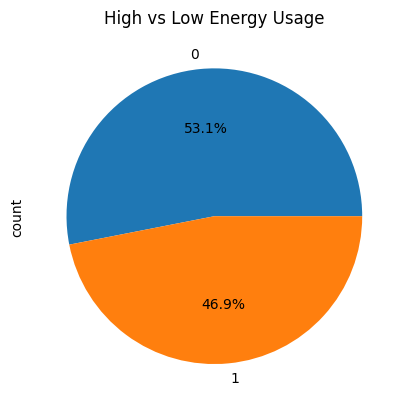

In [7]:
df['high_usage'].value_counts().plot.pie(autopct='%1.1f%%')
plt.title("High vs Low Energy Usage")
plt.show()

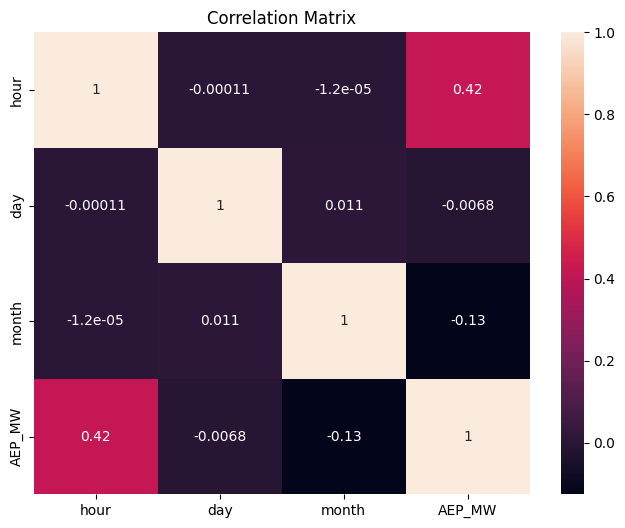

In [8]:
plt.figure(figsize=(8,6))
sns.heatmap(df[['hour','day','month','AEP_MW']].corr(), annot=True)
plt.title("Correlation Matrix")
plt.show()

In [9]:
X = df[['hour','day','month']]
y = df['high_usage']

In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

In [11]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression()
lr.fit(X_train, y_train)
pred_lr = lr.predict(X_test)

In [12]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
pred_knn = knn.predict(X_test)

In [13]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)

In [14]:
from sklearn.metrics import accuracy_score, precision_score, recall_score

print("----- Logistic Regression -----")
print("Accuracy:", accuracy_score(y_test, pred_lr))
print("Precision:", precision_score(y_test, pred_lr))
print("Recall:", recall_score(y_test, pred_lr))

print("\n----- KNN -----")
print("Accuracy:", accuracy_score(y_test, pred_knn))
print("Precision:", precision_score(y_test, pred_knn))
print("Recall:", recall_score(y_test, pred_knn))

print("\n----- Random Forest -----")
print("Accuracy:", accuracy_score(y_test, pred_rf))
print("Precision:", precision_score(y_test, pred_rf))
print("Recall:", recall_score(y_test, pred_rf))

----- Logistic Regression -----
Accuracy: 0.6489383632240775
Precision: 0.5269049332373871
Recall: 0.717239878101872

----- KNN -----
Accuracy: 0.7085961657390228
Precision: 0.5733564013840831
Recall: 0.901719634305616

----- Random Forest -----
Accuracy: 0.7573696145124716
Precision: 0.627538806085412
Recall: 0.8844144536351763


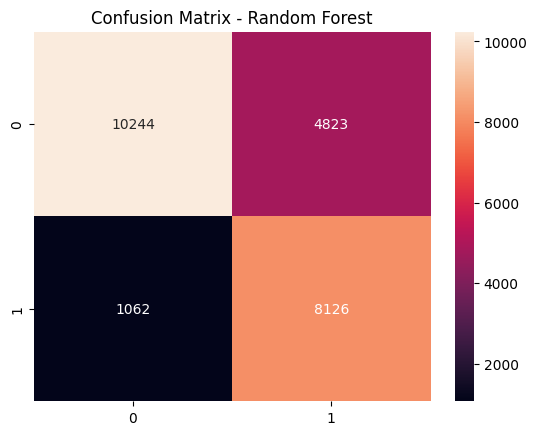

In [15]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, pred_rf)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix - Random Forest")
plt.show()


In [18]:
df.to_csv("cleaned_energy.csv", index=False)

print("\nProject Completed Successfully 🚀")


Project Completed Successfully 🚀
